In [1]:
import numpy as np
# import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import matplotlib.colors as mcol
import pygmt
# font = {'family' : 'Helvetica',
#         'weight' : 'normal',
#         'size'   : 10}

# plt.rc('legend',fontsize=8, title_fontsize=8)
# mpl.rc('font', **font)

In [2]:
inventory = pd.read_excel('/Volumes/SAF_Data/SAF_Data/remote-data/watermasks/admin/inventory-offline.xlsx', 
                          sheet_name='inventory_py', index_col = 0)
inventory = inventory.drop(index = 'agubh2')

/Users/safiya/anaconda3/envs/pygmt/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/safiya/anaconda3/envs/pygmt/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [6]:
np.log10(inventory['mean_discharge_global_m3/s'])

river
amudaryadown         3.351379
amudaryanew          3.342470
betsiboka            2.783116
bhareli_wide         3.046661
brahmaputra_pandu    4.057192
colville             2.292612
congo_destriped      4.667352
indus_r2             3.424309
irrawaddy            4.050072
irrawaddy_up         3.678039
kasai_destriped      3.853997
lena                 3.762738
mangoky              2.678242
ob_down              3.013663
ob_up                2.910206
rakaia               2.332260
southsask            2.355300
tanana               2.430266
yukon_eagle          3.248923
yukon                3.269845
Name: mean_discharge_global_m3/s, dtype: float64

In [33]:
data_sizes = np.floor(np.log10(inventory['mean_discharge_global_m3/s']))
data_sizes[data_sizes == 4.0] = 6.0
data_sizes[data_sizes == 3.0] = 4.5
data_sizes[data_sizes == 2.0] = 3.0

print(data_sizes)
size_labels = ['10e3-0e4', '10e4-10e5', '10e5-10e6']
size_values =[0.2, 0.4, 0.6]

river
amudaryadown         4.5
amudaryanew          4.5
betsiboka            3.0
bhareli_wide         4.5
brahmaputra_pandu    6.0
colville             3.0
congo_destriped      6.0
indus_r2             4.5
irrawaddy            6.0
irrawaddy_up         4.5
kasai_destriped      4.5
lena                 4.5
mangoky              3.0
ob_down              4.5
ob_up                3.0
rakaia               3.0
southsask            3.0
tanana               3.0
yukon_eagle          4.5
yukon                4.5
Name: mean_discharge_global_m3/s, dtype: float64


In [14]:
np.floor(np.log10(inventory['unit_sedflux_m2yr']))

river
amudaryadown         4.0
amudaryanew          4.0
betsiboka            4.0
bhareli_wide         5.0
brahmaputra_pandu    4.0
colville             4.0
congo_destriped      4.0
indus_r2             3.0
irrawaddy            5.0
irrawaddy_up         4.0
kasai_destriped      4.0
lena                 3.0
mangoky              4.0
ob_down              3.0
ob_up                3.0
rakaia               3.0
southsask            3.0
tanana               3.0
yukon_eagle          3.0
yukon                4.0
Name: unit_sedflux_m2yr, dtype: float64

In [15]:
qs_fill = np.floor(np.log10(inventory['unit_sedflux_m2yr']))

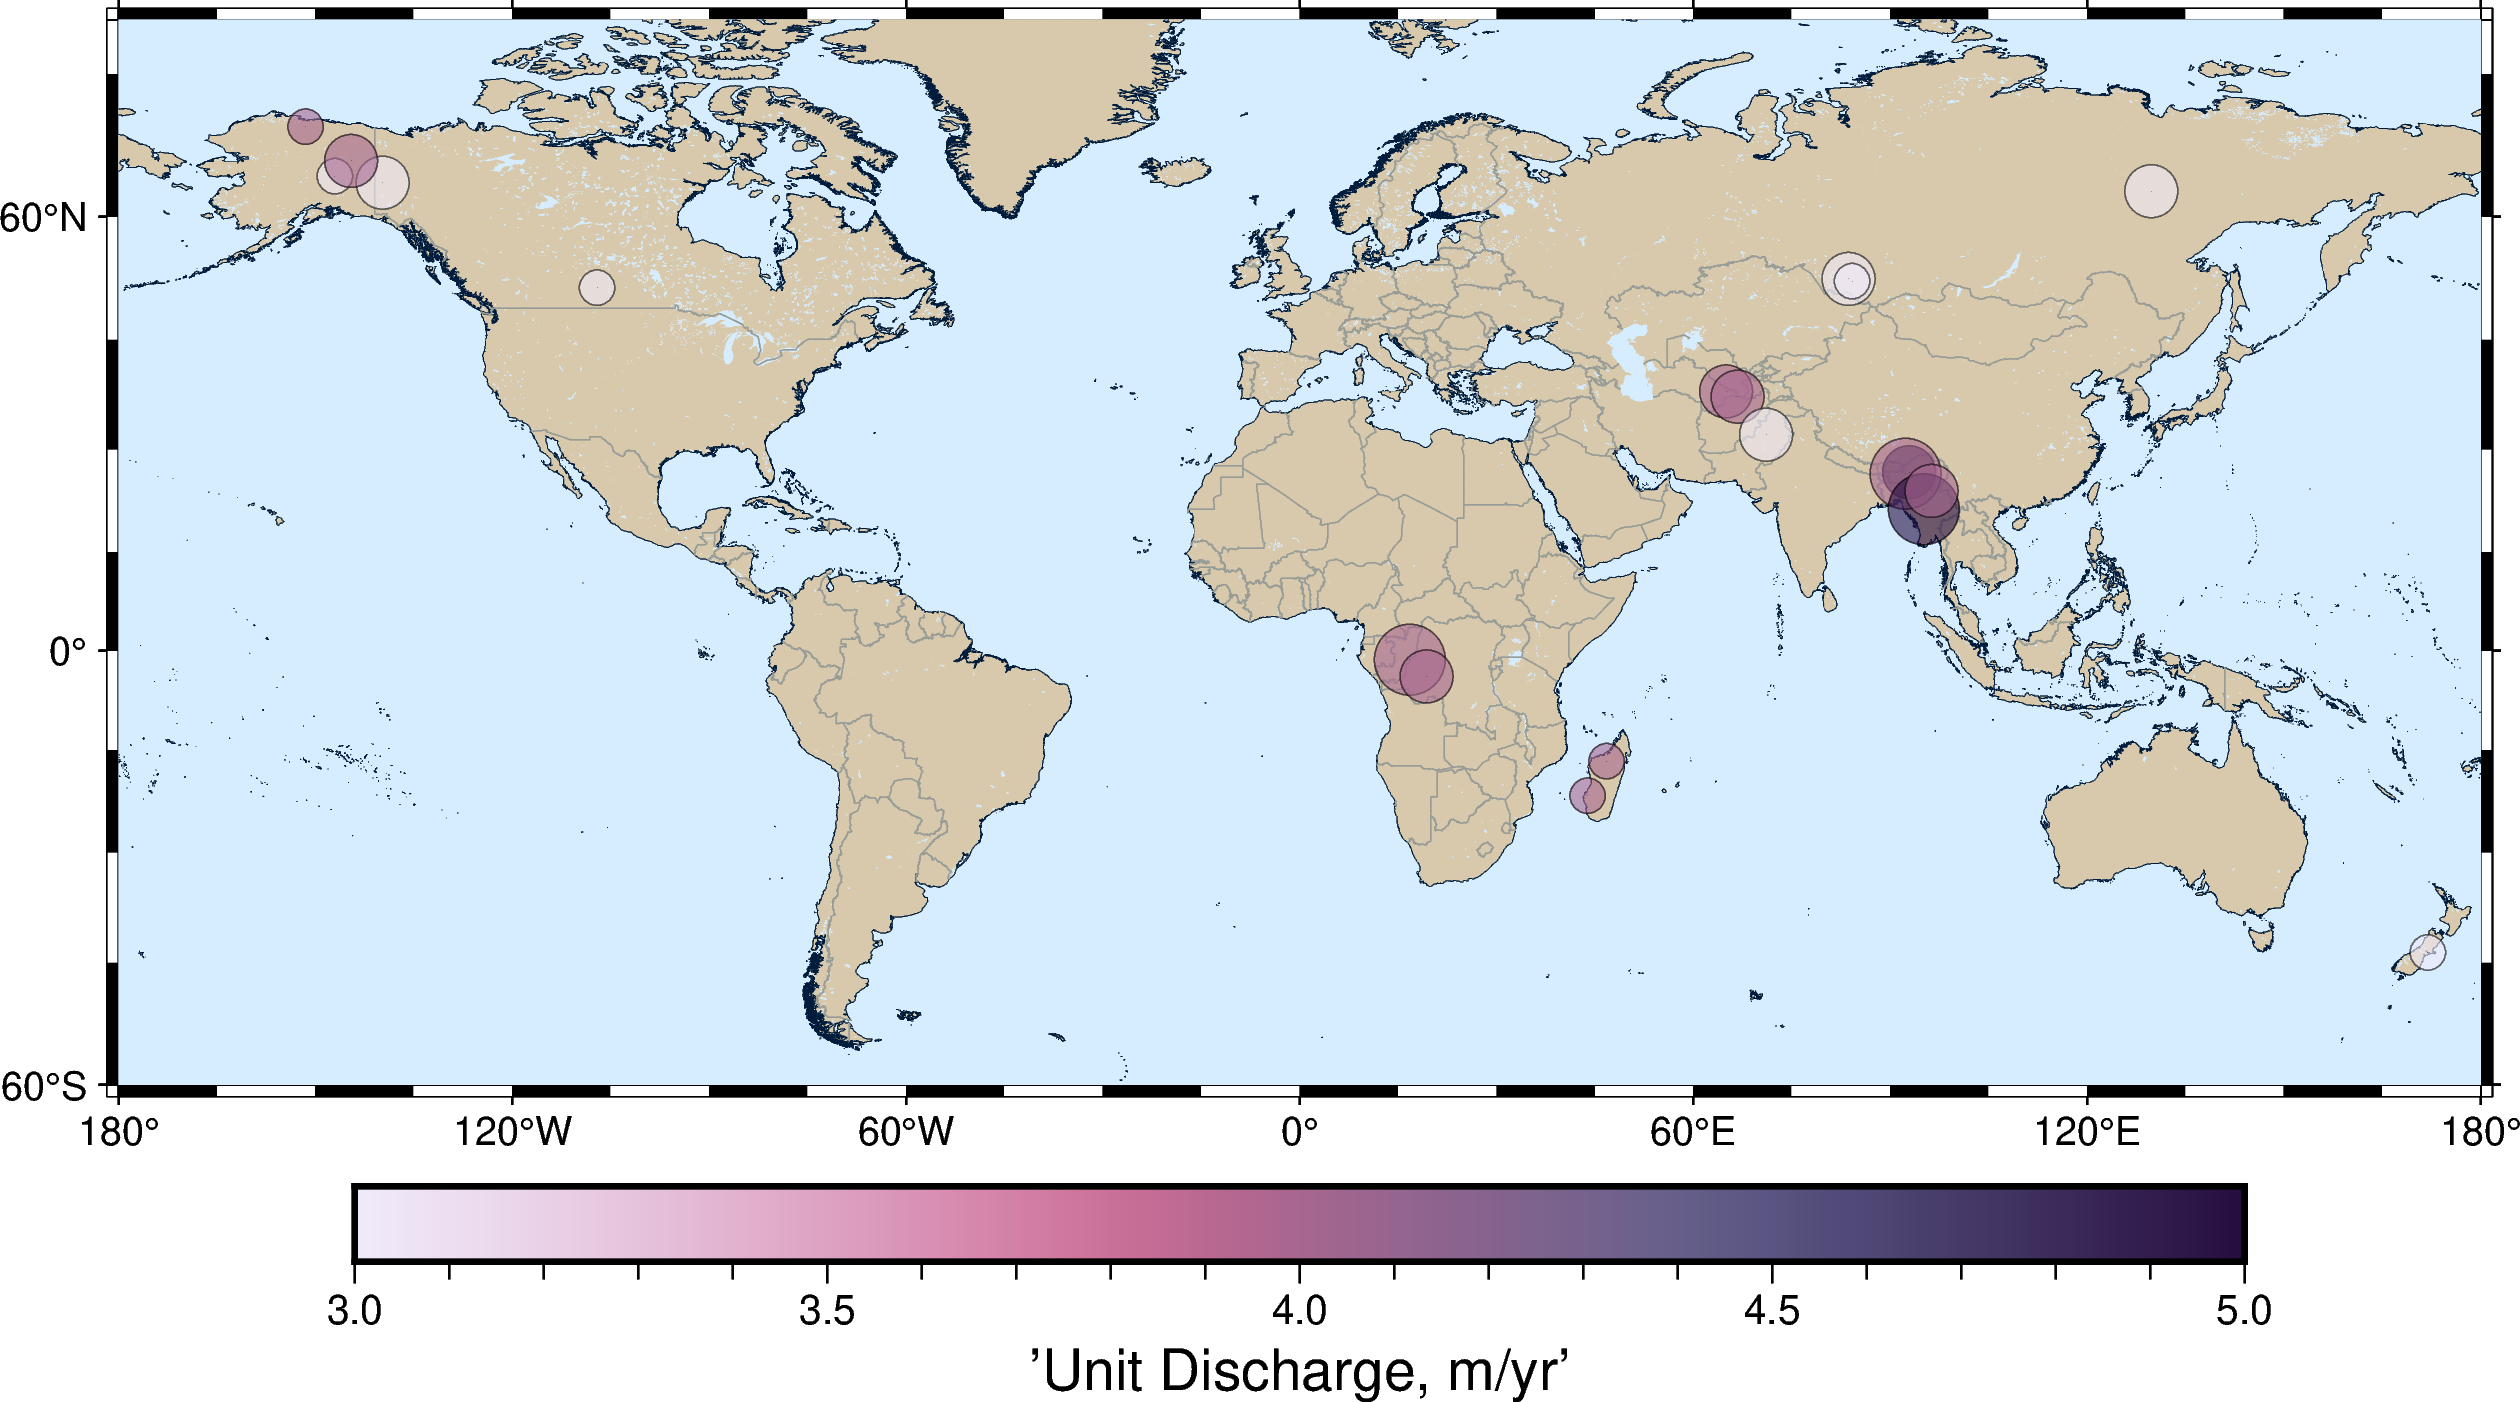

In [34]:
fig = pygmt.Figure()
## make a gmt cmap scaled to the data
cmap = pygmt.makecpt(cmap = 'SCM/acton', series = [qs_fill.min(), 
                                                        qs_fill.max()], reverse = True)# inventory['unit_discharge_m2s'].max()])
fig.basemap(region=[-180, 180, -60, 80], projection="Cyl_stere/0/0/20c", frame=["af", "WSne"])
# fig.basemap(region='d', projection="N12c", frame = True)

fig.coast(shorelines="1/0.1p, #001c3d", resolution = 'h', land = '#d8c9ac', water = '#d6edff', borders = "1/0.25p, #989c96")
fig.plot(x = inventory['longitude'], y = inventory['latitude'], size = 0.1*data_sizes, style = 'cc', 
         fill = qs_fill, cmap = True, pen = 'black', transparency = 40)
fig.plot(x = inventory['longitude'], y = inventory['latitude'], size = 10, style = 'cc', 
         fill = 'black', pen = 'black')
fig.colorbar(
    cmap=cmap,
    frame="af+l'Unit Discharge, m/yr'"
)

fig.show()

fig.savefig('/Volumes/SAF_Data/SAF_Data/remote-data/manuscript_figs/colby_qs_worldmap.png', crop = True, dpi = 500)

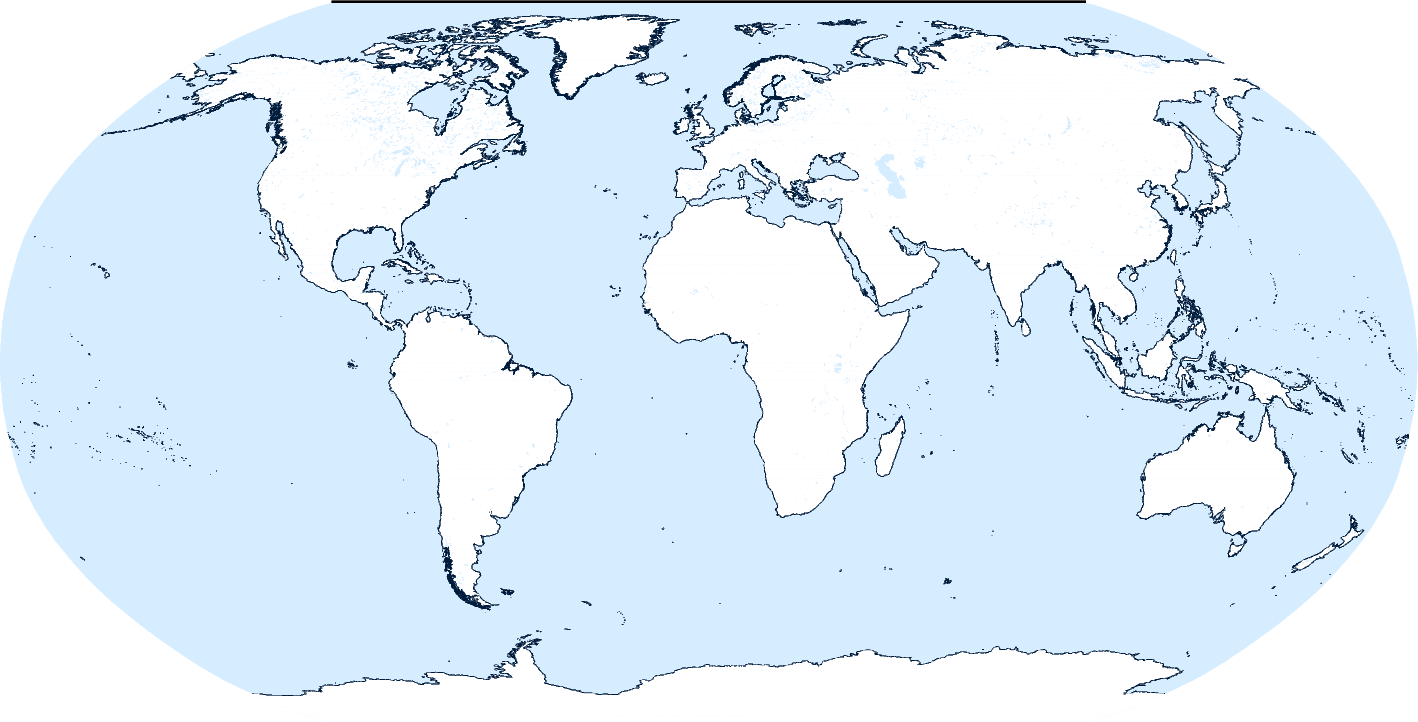

In [17]:
fig = pygmt.Figure()
## make a gmt cmap scaled to the data
# cmap = pygmt.makecpt(cmap = 'SCM/acton', series = [qs_fill.min(), 
#                                                         qs_fill.max()], reverse = True)# inventory['unit_discharge_m2s'].max()])
# fig.basemap(region=[-180, 180, -60, 80], projection="Cyl_stere/0/0/20c", frame=False)
fig.basemap(region='d', projection="N12c", frame = 'n')

fig.coast(shorelines="1/0.1p, #001c3d", resolution = 'h', land = 'white', water = '#d6edff', borders = "1/0.01p, #ffffff")
# fig.plot(x = inventory['longitude'], y = inventory['latitude'], size = 0.1*data_sizes, style = 'cc', 
#          fill = qs_fill, cmap = True, pen = 'black', transparency = 40)
# fig.plot(x = inventory['longitude'], y = inventory['latitude'], size = 10, style = 'cc', 
#          fill = 'black', pen = 'black')
# fig.colorbar(
#     cmap=cmap,
#     frame="af+l'Unit Discharge, m/yr'"
# )

fig.show()
fig.savefig('/Users/safiya/Desktop/globe_nocountries.eps')
# fig.savefig('/Volumes/SAF_Data/SAF_Data/remote-data/manuscript_figs/colby_qs_worldmap.png', crop = True, dpi = 500)